In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [29]:
df = pd.read_csv('Final_Project_Cleaned.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0.0,No,Yes,3.0,Yes,Yes,No,No,...,No,No,No,No,Month-to-month,No,Mailed check,68.61,205.83,1.0
1,CUST00002,Male,1.0,Yes,No,2.0,Yes,Yes,DSL,No,...,No,Yes,Unknown,No,One year,Yes,Bank transfer (automatic),23.15,46.30,0.0
2,CUST00003,Female,0.0,No,No,42.0,Yes,Yes,DSL,No,...,No,Unknown,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,1.0
3,CUST00004,Female,0.0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,75.04,3001.60,0.0
4,CUST00005,Male,1.0,Yes,Yes,17.0,Yes,Unknown,Fiber optic,Yes,...,Yes,No,No,No,Two year,Yes,Electronic check,22.38,380.46,1.0


--- 📊 Churn Distribution Numbers ---
Churn
0.0    36658
1.0    32342
Name: count, dtype: int64


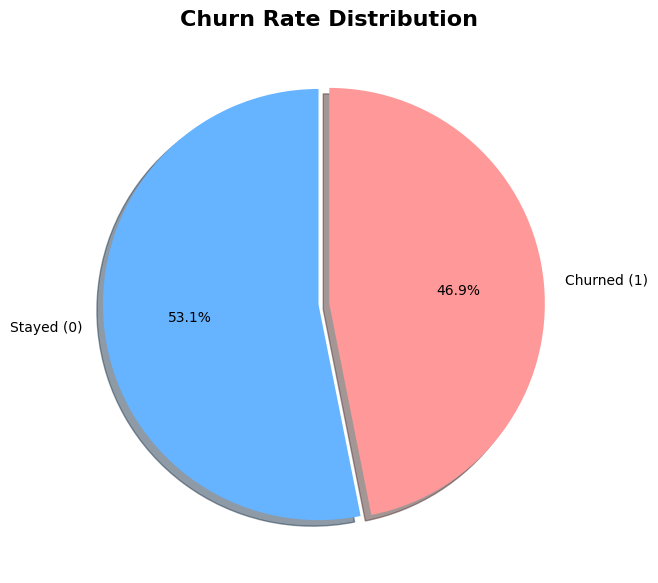

In [30]:
churn_counts = df['Churn'].value_counts()

print("--- 📊 Churn Distribution Numbers ---")
print(churn_counts)

plt.figure(figsize=(7, 7))
plt.pie(churn_counts,
        labels=['Stayed (0)', 'Churned (1)'],
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'],
        startangle=90,
        explode=(0.05, 0),
        shadow=True)

plt.title('Churn Rate Distribution', fontsize=16, fontweight='bold')
plt.show()

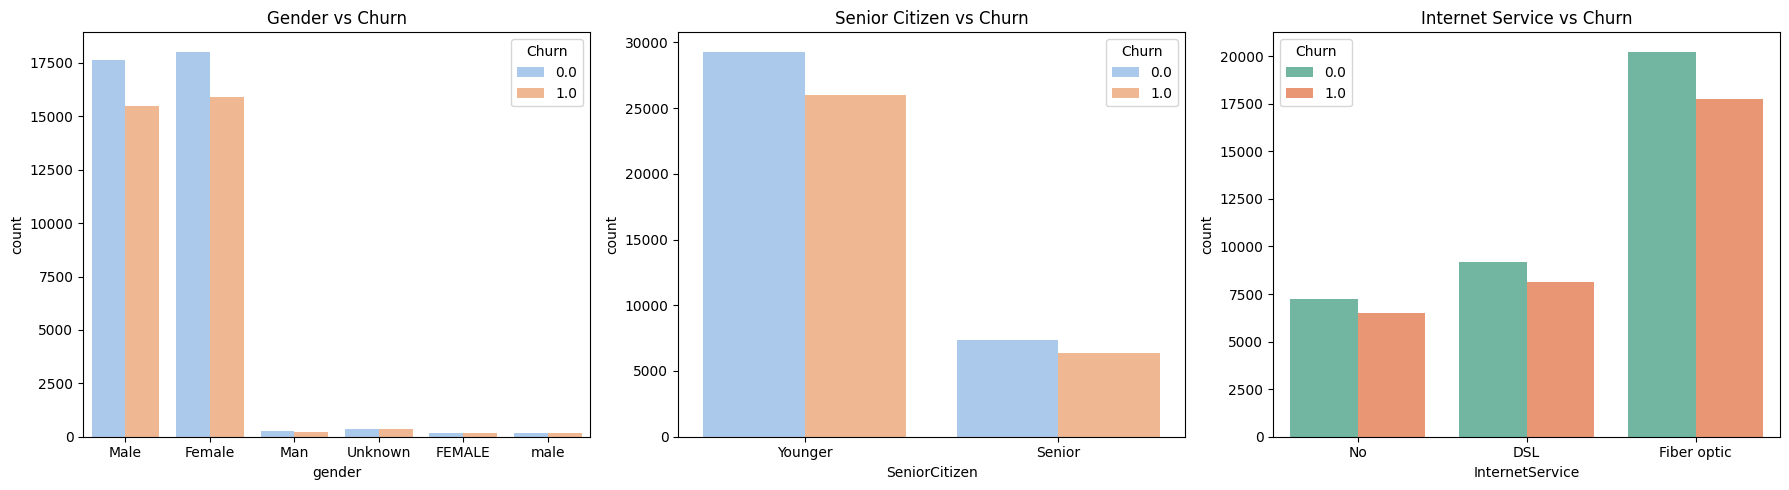

In [31]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='gender', hue='Churn', data=df, palette='pastel')
plt.title('Gender vs Churn')

plt.subplot(1, 3, 2)
# عشان الرسمة تبقى مفهومة، هنغير 0 و 1
sns.countplot(x=df['SeniorCitizen'].map({0:'Younger', 1:'Senior'}), hue=df['Churn'], palette='pastel')
plt.title('Senior Citizen vs Churn')

plt.subplot(1, 3, 3)
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn')

plt.tight_layout()
plt.show()

In [32]:
print(df['gender'].unique())
print(df['gender'].value_counts())

['Male' 'Female' 'Man' 'Unknown' 'FEMALE' 'male']
gender
Female     33955
Male       33099
Unknown      735
Man          496
male         368
FEMALE       347
Name: count, dtype: int64


In [33]:
df['gender'] = df['gender'].str.capitalize()
df['gender'] = df['gender'].replace({'Man': 'Male'})

In [34]:
df['gender'] = df['gender'].replace('Unknown', np.nan)
df = df.dropna(subset=['gender'])

In [35]:
print(df['gender'].unique())

['Male' 'Female']


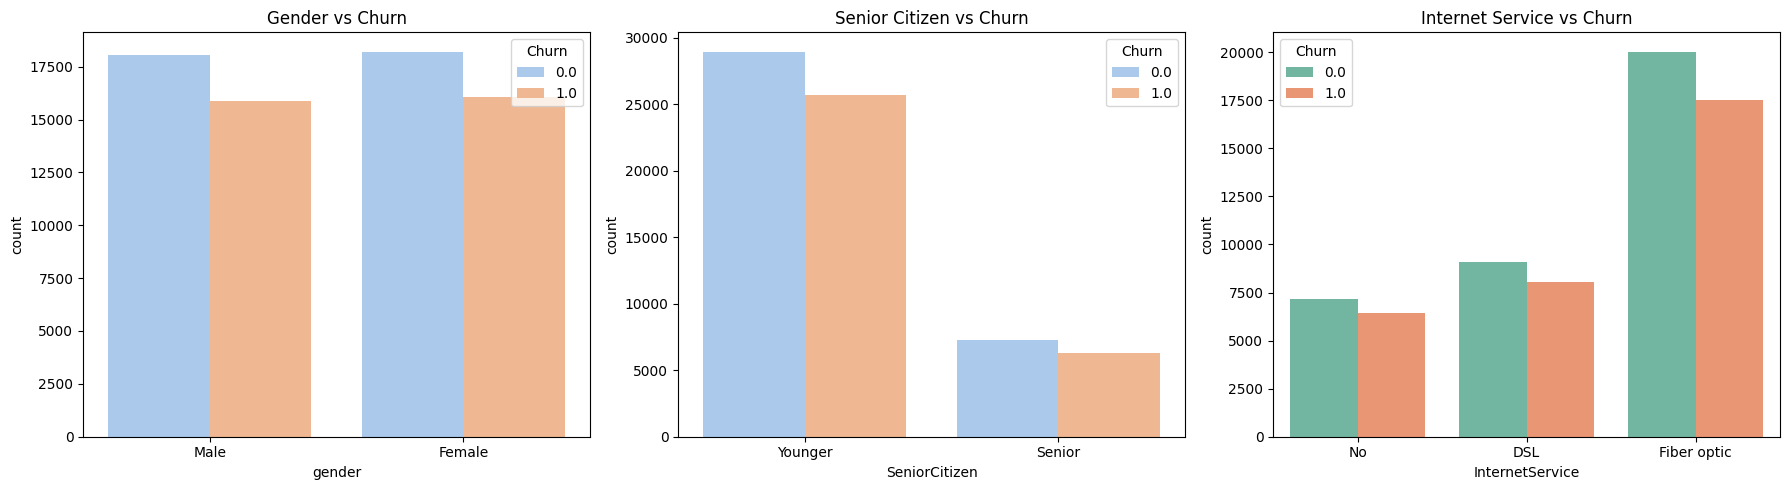

In [36]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.countplot(x='gender', hue='Churn', data=df, palette='pastel')
plt.title('Gender vs Churn')

plt.subplot(1, 3, 2)
# عشان الرسمة تبقى مفهومة، هنغير 0 و 1
sns.countplot(x=df['SeniorCitizen'].map({0:'Younger', 1:'Senior'}), hue=df['Churn'], palette='pastel')
plt.title('Senior Citizen vs Churn')

plt.subplot(1, 3, 3)
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn')

plt.tight_layout()
plt.show()

In [37]:
pd.crosstab(df['gender'], df['Churn'], normalize='index')


Churn,0.0,1.0
gender,,
Female,0.530989,0.469011
Male,0.531902,0.468098


In [38]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')


Churn,0.0,1.0
SeniorCitizen,,
0.0,0.530085,0.469915
1.0,0.536901,0.463099


In [39]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

Churn,0.0,1.0
InternetService,,
DSL,0.530555,0.469445
Fiber optic,0.533236,0.466764
No,0.527604,0.472396


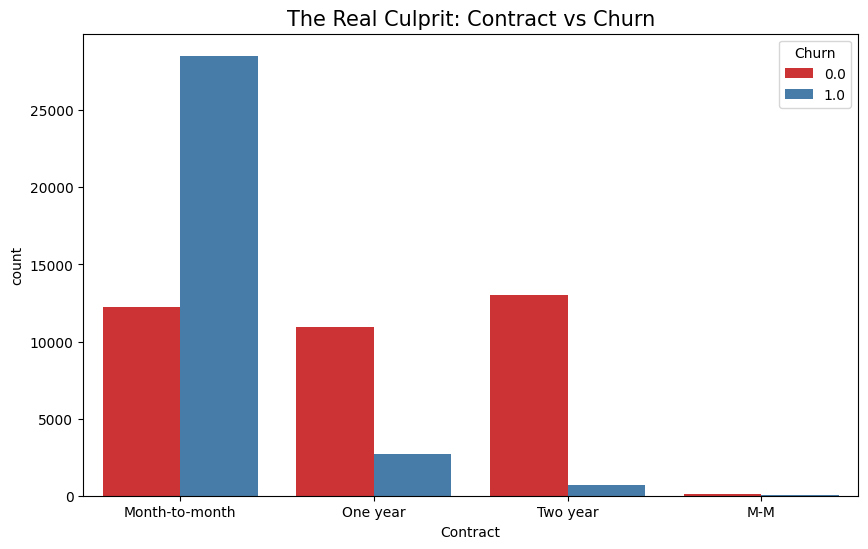

Churn                 0.0        1.0
Contract                            
M-M             53.614458  46.385542
Month-to-month  30.025745  69.974255
One year        80.228471  19.771529
Two year        95.094450   4.905550


In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('The Real Culprit: Contract vs Churn', fontsize=15)
plt.show()

print(pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100)

In [41]:
df["Contract"] = df["Contract"].replace({"M-M":"Month-to-month"})

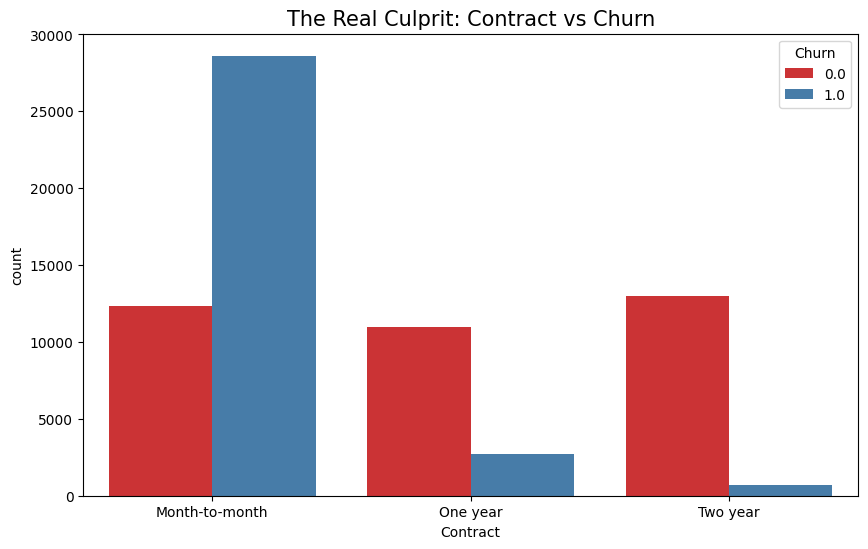

Churn                 0.0        1.0
Contract                            
Month-to-month  30.121365  69.878635
One year        80.228471  19.771529
Two year        95.094450   4.905550


In [42]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')
plt.title('The Real Culprit: Contract vs Churn', fontsize=15)
plt.show()

print(pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100)

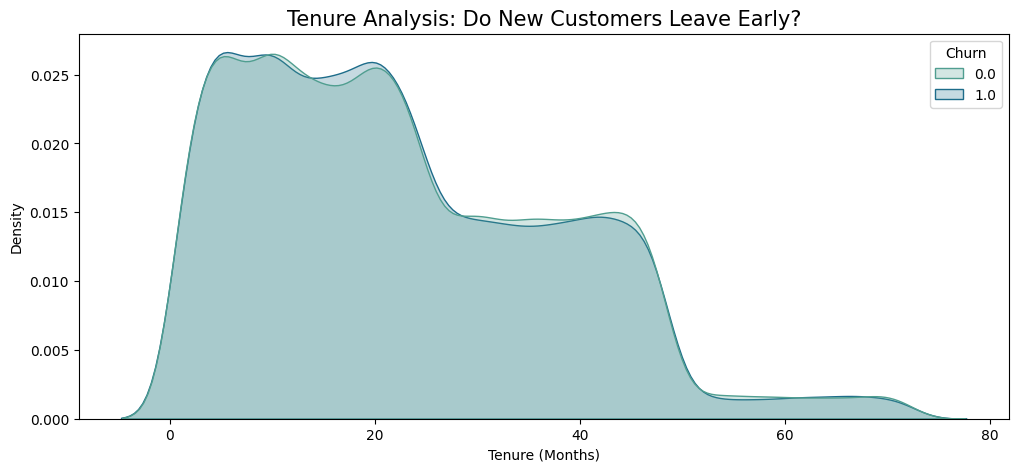

In [43]:
plt.figure(figsize=(12, 5))

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Tenure Analysis: Do New Customers Leave Early?', fontsize=15)
plt.xlabel('Tenure (Months)')

plt.show()

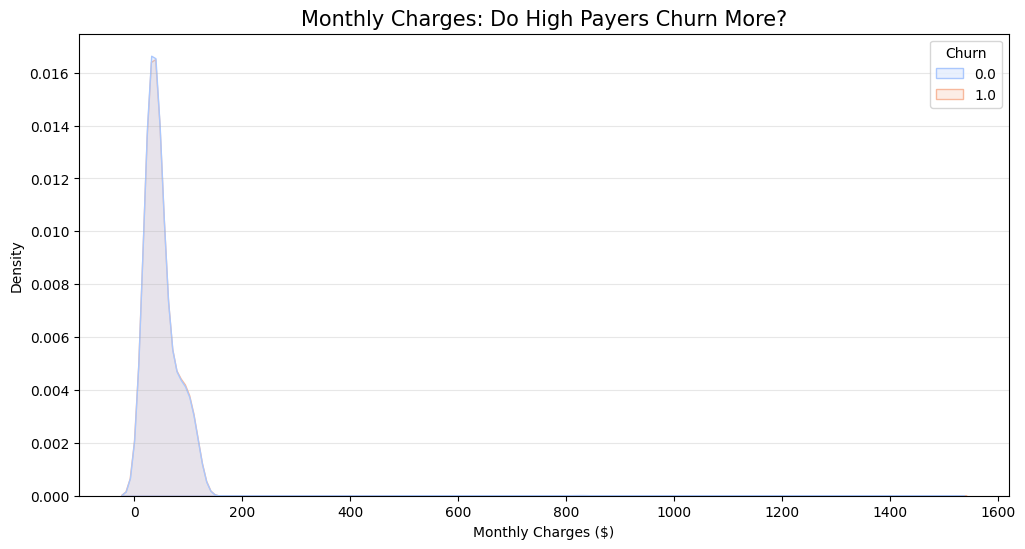

In [44]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette="coolwarm")

plt.title('Monthly Charges: Do High Payers Churn More?', fontsize=15)
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
plt.show()

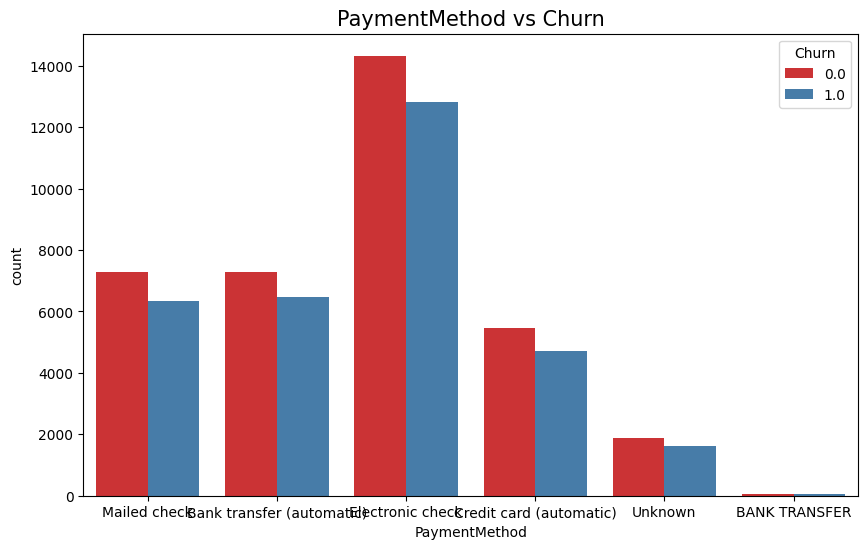

Churn                           0.0       1.0
PaymentMethod                                
BANK TRANSFER              0.495935  0.504065
Bank transfer (automatic)  0.530057  0.469943
Credit card (automatic)    0.536713  0.463287
Electronic check           0.527951  0.472049
Mailed check               0.534783  0.465217
Unknown                    0.536978  0.463022


In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set1')
plt.title('PaymentMethod vs Churn', fontsize=15)
plt.show()

print(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index'))


In [46]:
# كان بيديلي ايروي في الcell اللي تحته
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

customerID: 68265 unique values
gender: 2 unique values
Partner: 3 unique values
Dependents: 3 unique values
PhoneService: 2 unique values
MultipleLines: 4 unique values
InternetService: 3 unique values
OnlineSecurity: 5 unique values
OnlineBackup: 5 unique values
DeviceProtection: 5 unique values
TechSupport: 5 unique values
StreamingTV: 5 unique values
StreamingMovies: 5 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 6 unique values


In [47]:
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

In [48]:
# الكود ده بيلف على كل عمود وبيصلح "الكوكتيل"
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({
            'Yes': 'Yes', 'yes': 'Yes', 'True': 'Yes', 'true': 'Yes',
            'No': 'No', 'no': 'No', 'False': 'No', 'false': 'No'})

# 2. تحويل الـ Churn لأرقام (لو لسه محصلش)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# 3. التحويل النهائي (Get Dummies)
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. نشوف بقى الـ Correlation الحقيقي
print("--- Top 10 Positive Correlations ---")
print(df_encoded.corr()['Churn'].sort_values(ascending=False).head(10))

print("\n--- Top 10 Negative Correlations (Prevent Churn) ---")
print(df_encoded.corr()['Churn'].sort_values().head(10))

--- Top 10 Positive Correlations ---
Churn                                      1.000000
Dependents_Unknown                         0.007429
Partner_Yes                                0.007283
PaymentMethod_Electronic check             0.005686
OnlineBackup_Yes                           0.004038
InternetService_No                         0.003832
MultipleLines_No phone service             0.003175
MultipleLines_Unknown                      0.002249
PaymentMethod_Bank transfer (automatic)    0.001396
PaperlessBilling_Yes                       0.000813
Name: Churn, dtype: float64

--- Top 10 Negative Correlations (Prevent Churn) ---
Contract_Two year     -0.420429
Contract_One year     -0.271415
StreamingMovies_Yes   -0.009149
StreamingTV_Y         -0.007188
OnlineSecurity_Yes    -0.007145
OnlineBackup_Y        -0.006514
StreamingMovies_Y     -0.005672
SeniorCitizen         -0.005456
tenure                -0.005280
TechSupport_Unknown   -0.004572
Name: Churn, dtype: float64


In [49]:
# بنلف على كل العواميد ونوحد اللغة
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({
            'Y': 'Yes', 'y': 'Yes',
            'Yes': 'Yes', 'True': 'Yes', 'true': 'Yes',
            'No': 'No', 'False': 'No', 'false': 'No'})


# عشان نشوف كل العواميد
df_final = pd.get_dummies(df, drop_first=False)

# 3. نشوف الـ Correlation للمرة الأخيرة
print("--- Top 5 Reasons for Churn (Positive) ---")
print(df_final.corr()['Churn'].sort_values(ascending=False).head(6)) # head(6) عشان نشيل الـ Churn نفسه

--- Top 5 Reasons for Churn (Positive) ---
Churn                      1.000000
Contract_Month-to-month    0.564927
StreamingMovies_No         0.008146
OnlineSecurity_No          0.007472
Dependents_Unknown         0.007429
Partner_Yes                0.007283
Name: Churn, dtype: float64


In [50]:
df.to_csv('Final_Project_very_Cleaned.csv', index=False)